# Problema de Classificação

## Objetivo

O objetivo deste notebook é resolver um problema de classificação de ponta a ponta, desde a análise e preparação dos dados até a construção e avaliação de um modelo de Machine Learning.

## Problema de Negócio

Uma empresa de telecomunicações está enfrentando um problema com a perda de clientes para concorrentes (um fenômeno conhecido como **churn**). Para mitigar isso, a empresa quer construir um modelo preditivo que possa identificar clientes com alta probabilidade de cancelar seus serviços.

---

In [1]:
# Importação de bibliotecas básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de visualização
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Bibliotecas de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Ignorar warnings para uma melhor apresentação
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Carregamento dos dados
# O dataset está disponível publicamente em um repositório do GitHub.
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)

# Visualizando as primeiras linhas
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 2. Análise Exploratória de Dados (EDA)

Agora, vamos explorar os dados para entender suas características, identificar problemas (como dados faltantes) e encontrar padrões que possam nos ajudar a construir o modelo.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


#### 2.1 Limpeza e Tratamento Inicial

A coluna `TotalCharges` foi lida como `object`, mas deveria ser numérica. Isso geralmente indica a presença de valores não numéricos. Vamos investigar e corrigir.

In [4]:
# Tentando converter 'TotalCharges' para numérico
# O argumento `errors='coerce'` transformará valores problemáticos em NaN (Not a Number)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Verificando valores nulos após a conv
print("\nContagem de valores nulos na coluna TotalCharges:")
print(df['TotalCharges'].isnull().sum())
df['TotalCharges'].info()




Contagem de valores nulos na coluna TotalCharges:
11
<class 'pandas.core.series.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: TotalCharges
Non-Null Count  Dtype  
--------------  -----  
7032 non-null   float64
dtypes: float64(1)
memory usage: 55.2 KB


In [5]:
# Os valores nulos em 'TotalCharges' correspondem a clientes com 'tenure' (tempo de contrato) igual a 0.
# Vamos preencher esses valores nulos com 0, pois faz sentido que um cliente novo não tenha cobranças totais.
df['TotalCharges'].fillna(0.0, inplace=True)

# Verificando novamente se ainda há nulos
print("\nValores nulos restantes em 'TotalCharges':")
print(df['TotalCharges'].isnull().sum())
print("\ntipo da coluna TotalCharges:")
print(df['TotalCharges'].dtype)


Valores nulos restantes em 'TotalCharges':
0

tipo da coluna TotalCharges:
float64


In [6]:
#a coluna customerID é um identificador único e não tem valor preditivo para o modelo.
#deve ser removido antes de prosseguir com a modelagem.
# Removendo a coluna CustomerID
df.drop('customerID', axis=1, inplace=True)

print(df.columns)

print("\nVerificação final dos tipos de dados:")
df.info()



Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Verificação final dos tipos de dados:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecuri

#### 2.2 Análise da Variável Alvo (`Churn`)

Vamos analisar a distribuição da nossa variável alvo para entender o balanceamento das classes.

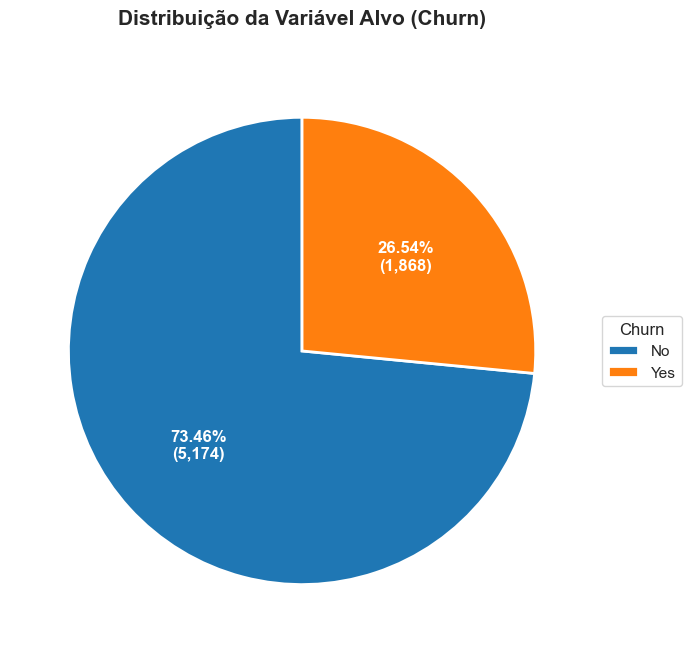

In [7]:
# Contagem da variável alvo
churn_counts = df['Churn'].value_counts()
churn_rates = round(df['Churn'].value_counts(normalize=True) * 100, 2)

# Gráfico de pizza
plt.figure(figsize=(7, 7))
plt.pie(
    churn_counts,
    labels=churn_counts.index,
    autopct=lambda x: f'{x:.2f}%\n({int(x * sum(churn_counts) / 100):,})',
    startangle=90,
    textprops={'fontsize': 12, 'weight': 'bold', 'color': 'white'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

plt.legend(
    [f'{label}' for label in churn_counts.index],
    title='Churn',
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    fontsize=11,
    title_fontsize=12
)

# Estilo do título
plt.title('Distribuição da Variável Alvo (Churn)', fontsize=15, fontweight='bold', pad=25)
plt.tight_layout()
plt.show()


A variável Churn mostra que apenas cerca de 26,5% dos clientes cancelaram o serviço, enquanto 73,5% permaneceram ativos.\
Isso indica que o cancelamento é um evento menos comum, e é justamente ele que interessa pra análise — entender quem cancela e por quê.

Por ser a classe minoritária, o “Yes” é mais difícil de prever. O modelo tende naturalmente a se concentrar no “No”,\
já que é o padrão mais frequente. O problema é que isso pode gerar um modelo que “parece bom”, mas não acerta os cancelamentos de verdade — o tipo de erro mais crítico pra empresa.

Por isso, as métricas mais importantes aqui não são a acurácia, mas sim o Recall, o Precision e o F1-Score,\
que mostram o quanto o modelo realmente reconhece e acerta os churners. O ROC AUC também ajuda a avaliar se o modelo sabe distinguir bem quem vai cancelar de quem vai ficar.

#### 2.3 Análise de Variáveis Categóricas vs. Churn

Vamos visualizar como diferentes variáveis categóricas se relacionam com a taxa de churn.

In [8]:
categorical_features = ['gender', 'SeniorCitizen', 'Partner', 
                        'Dependents', 'PhoneService', 'MultipleLines', 
                        'InternetService', 'OnlineSecurity', 'OnlineBackup', 
                        'DeviceProtection', 'TechSupport', 'StreamingTV', 
                        'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

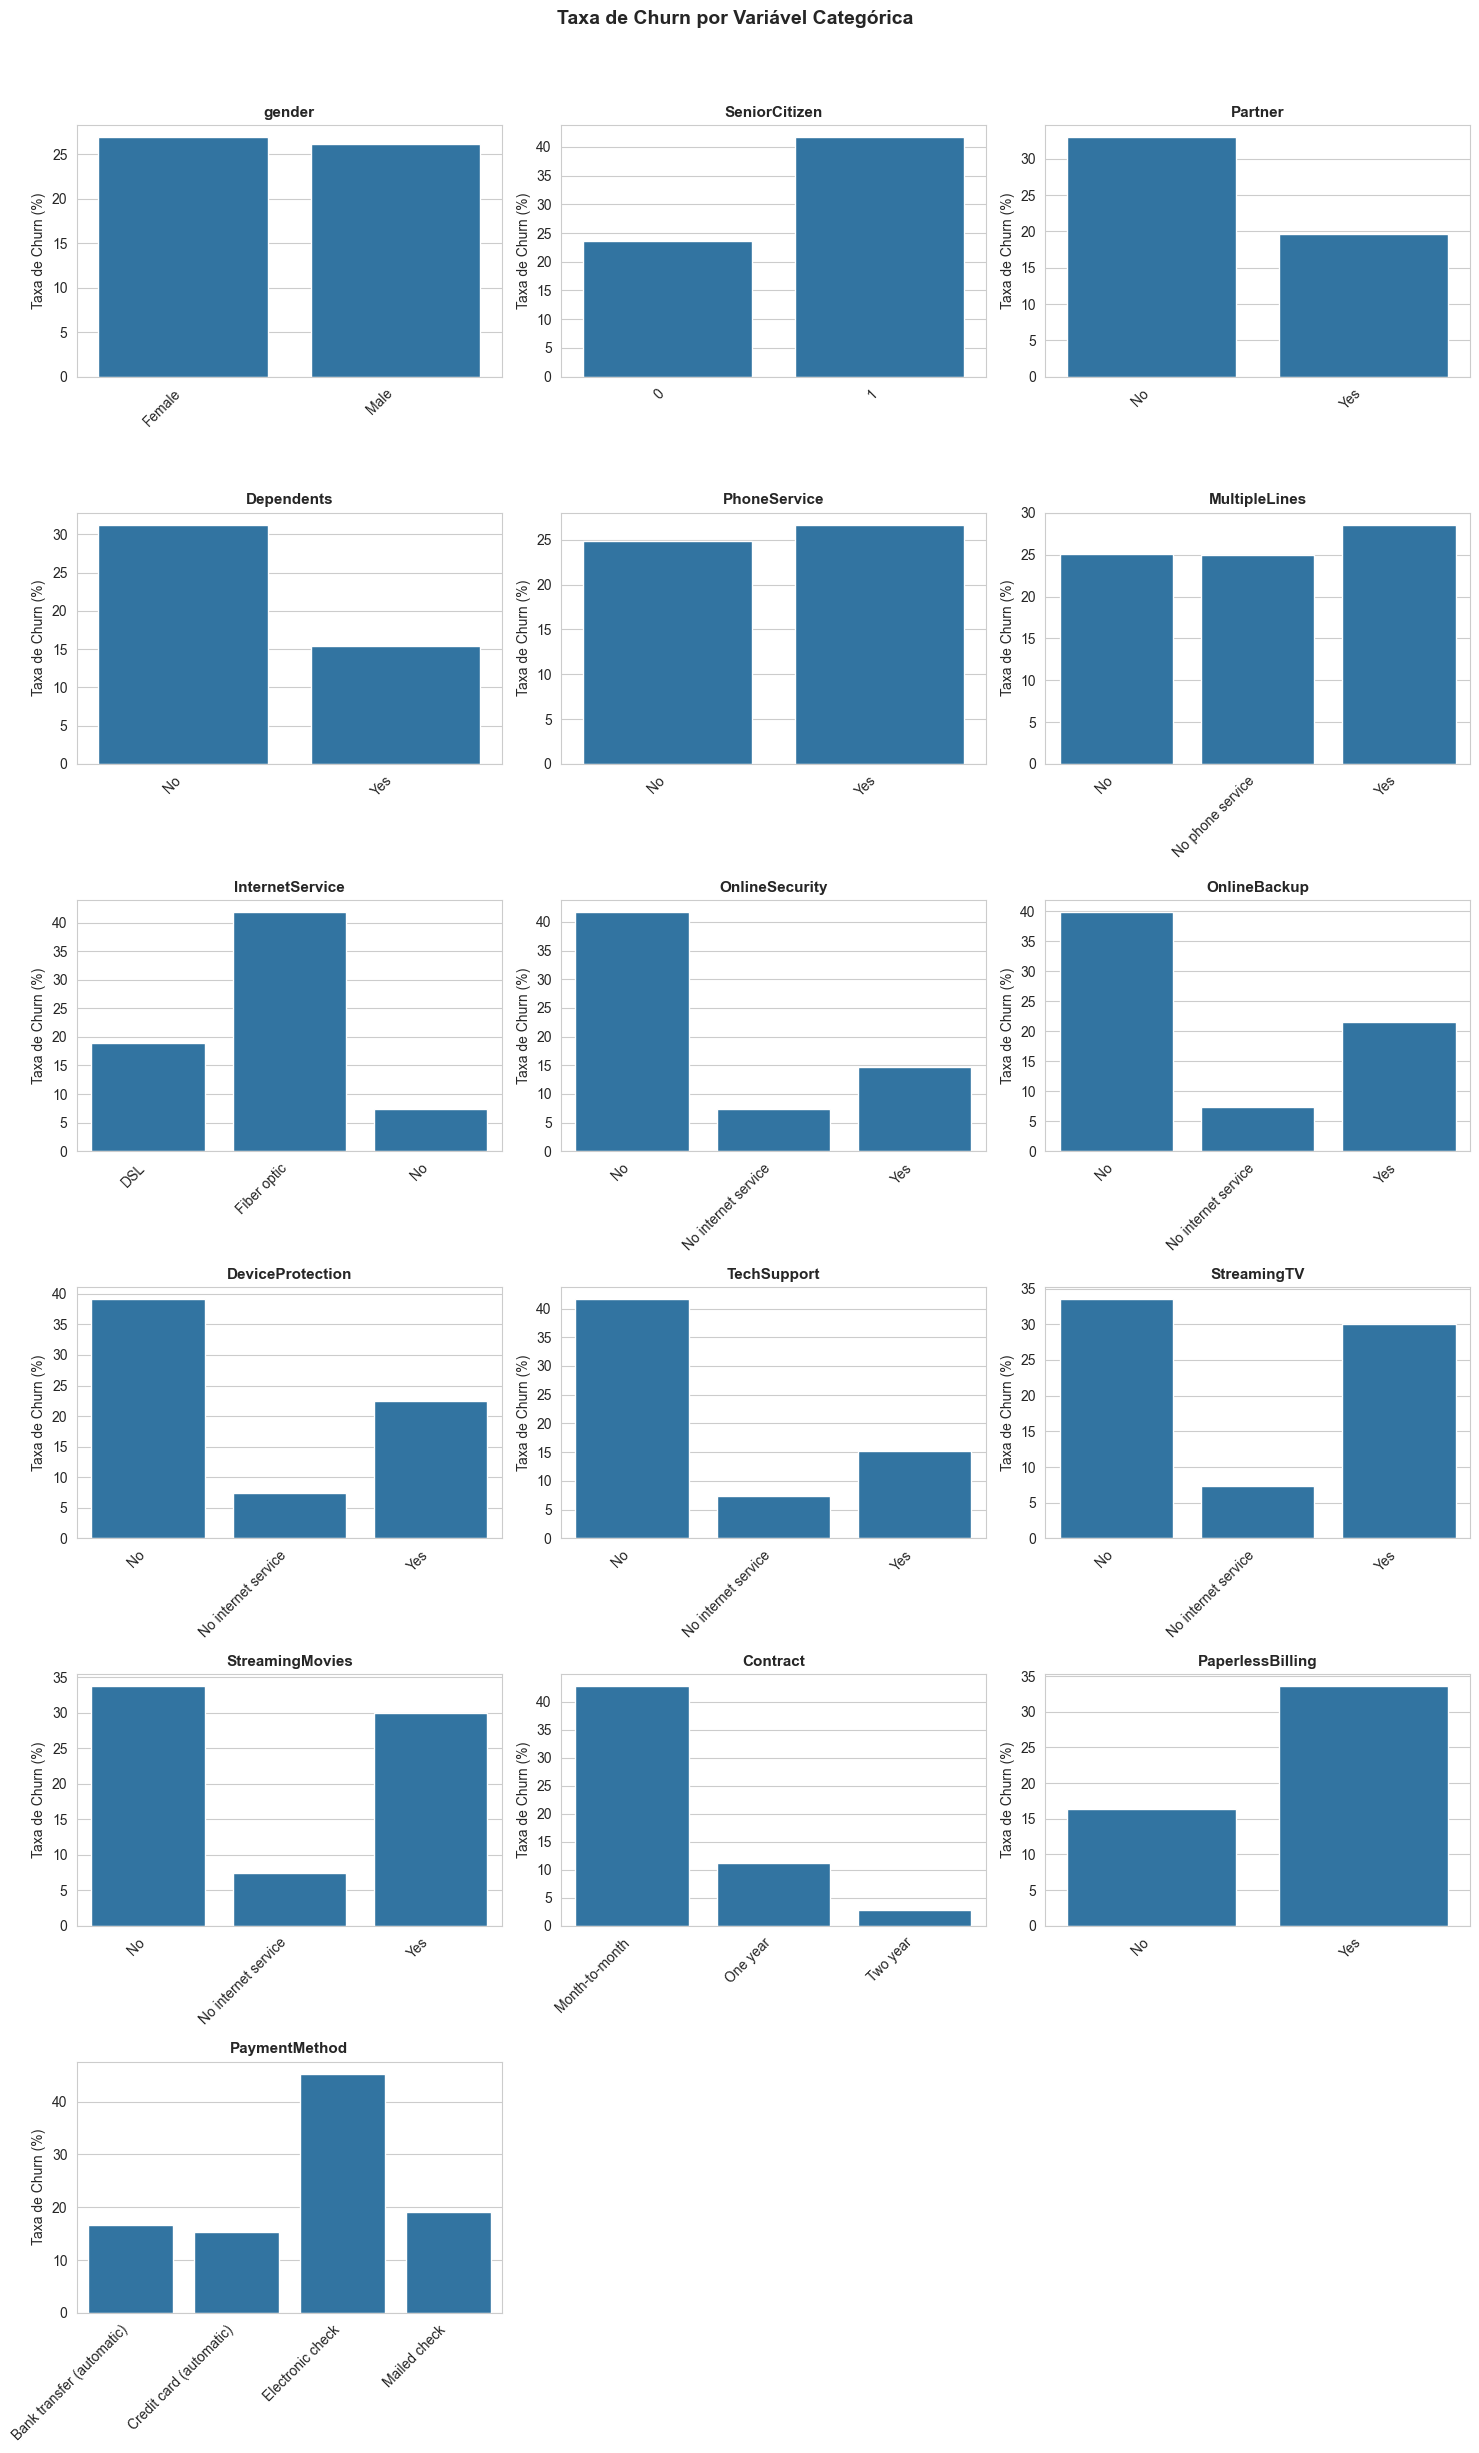

In [9]:
# Define layout dos subplots
n_cols = 3
n_rows = -(-len(categorical_features) // n_cols)

plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(categorical_features, 1):
    plt.subplot(n_rows, n_cols, i)
    
    churn_rate = (
        df.groupby(col)['Churn']
          .value_counts(normalize=True)
          .mul(100)
          .unstack(fill_value=0)
          .get('Yes', pd.Series(0))
    )

    sns.barplot(x=churn_rate.index, y=churn_rate.values)
    plt.title(f'{col}', fontsize=11, fontweight='bold')
    plt.ylabel('Taxa de Churn (%)')
    plt.xlabel('')
    plt.xticks(rotation=45, ha='right')

plt.suptitle('Taxa de Churn por Variável Categórica', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

1. **Contract (Tipo de Contrato)**\
Os clientes com contrato mês a mês tendem a cancelar com muito mais frequência do que aqueles com contratos de longo prazo,\
como anuais ou bianuais. Isso mostra que a duração do contrato é um dos fatores mais fortes de retenção: quem assume um vínculo\
mais longo costuma ser mais estável e leal à empresa.

2. **SeniorCitizen (Idoso)**\
Entre os clientes idosos, o cancelamento é mais comum. Esse grupo parece menos propenso a manter o serviço por muito tempo,\
talvez por menor familiaridade com tecnologia, por percepções diferentes de custo-benefício ou até por mudança de hábitos de consumo.

3. **PaymentMethod (Método de Pagamento)**\
Os clientes que usam cheque eletrônico como forma de pagamento costumam apresentar maior propensão ao churn. Esse padrão pode indicar\
que esse método é mais popular entre clientes menos estáveis financeiramente ou que enxergam o serviço como algo temporário, o que reforça um perfil de menor fidelidade.

4. **PaperlessBilling**\
A escolha pela fatura sem papel está associada a um churn mais alto, enquanto quem prefere a fatura física tende a ser mais estável. Isso não significa que o método de pagamento cause o cancelamento, mas indica um perfil de cliente: os que usam PaperlessBilling são geralmente mais digitais, atentos a ofertas e menos leais, enquanto os que recebem fatura impressa parecem mais tradicionais e fiéis ao serviço.

#### 2.4 Análise de Variáveis Numéricas vs. Churn

Agora, vamos analisar a relação entre as variáveis numéricas e o churn.

In [10]:
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

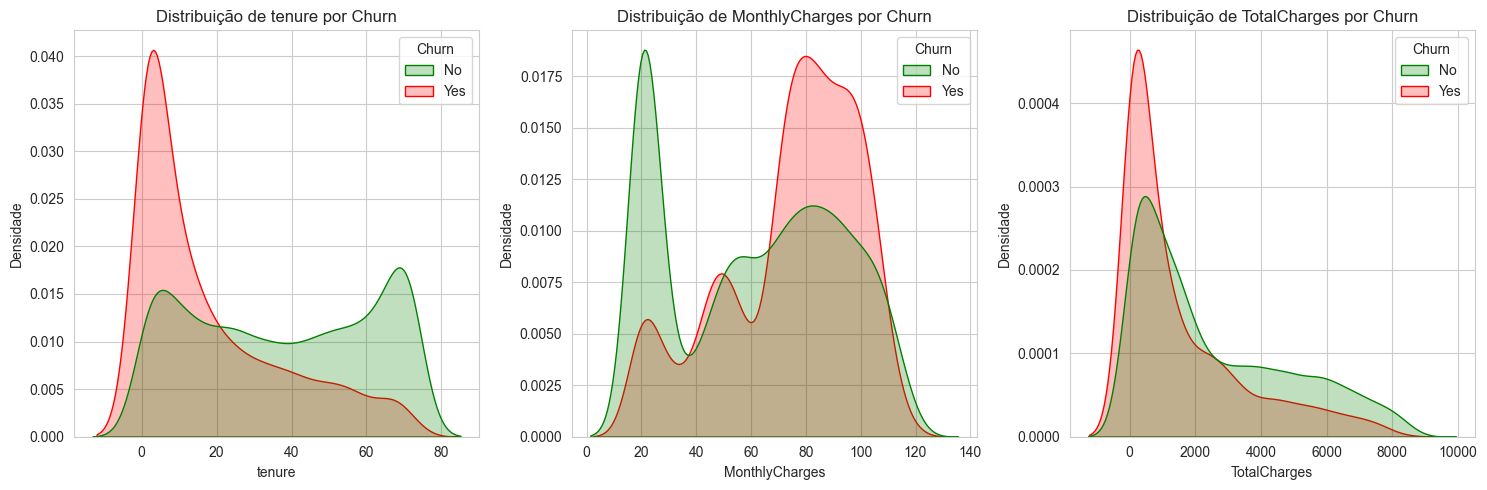

In [11]:
# plot as variáveis numericas vs Churn

# Gráficos de Box Plots e histogramas/KDE (Kernel Density Estimate)
plt.figure(figsize=(15, 5))

for i, col in enumerate(numerical_features):
    
    # Gráfico de Densidade (KDE Plot) para visualizar a distribuição e a separação
    plt.subplot(1, 3, i + 1)
    sns.kdeplot(data=df, x=col, hue='Churn', fill=True, common_norm=False, palette={'Yes': 'red', 'No': 'green'})
    plt.title(f'Distribuição de {col} por Churn', fontsize=12)
    plt.xlabel(col)
    plt.ylabel('Densidade')
    
plt.tight_layout()
plt.show()

O que os gráficos nos dizem sobre a relação entre tenure, MonthlyCharges e o churn?


1. **tenure - Tempo de Contrato**\
Padrão Observado: A relação é fortemente inversa.

    O churn é mais comum entre clientes recentes, especialmente nos primeiros meses de contrato. Quem permanece tende a ter um tempo de contrato mais longo,\
    mostrando que a fidelidade aumenta com a permanência. Ou seja, o tenure é um dos preditores mais fortes: baixo tenure indica maior risco de cancelamento,\
    enquanto alto tenure sugere lealdade.

2. **MonthlyCharges (Cobrança Mensal)**\
Padrão Observado: A relação é diretamente proporcional e polarizada.

    Clientes com mensalidades mais altas têm maior tendência a cancelar, enquanto aqueles com pacotes mais baratos permanecem. Há sobreposição nas faixas médias,\
    mas a tendência é clara: quanto mais caro o plano, maior o risco de churn.

Em resumo, o cliente mais propenso a cancelar é aquele que acabou de entrar na empresa (tenure baixo) e paga uma mensalidade alta (MonthlyCharges alto).

### 3. Pré-processamento e Feature Engineering

Nesta etapa, prepararemos os dados para serem usados pelos modelos de Machine Learning. Isso inclui:
-   Remover colunas desnecessárias.
-   Codificar variáveis categóricas.
-   Escalonar variáveis numéricas.
-   Dividir os dados em conjuntos de treino e teste.

In [12]:
# A coluna 'customerID' é um identificador único e não deve ser usada no modelo.
print("A coluna 'customerID' já foi removida nao ponto 2.1")

# Convertendo a variável alvo para formato numérico (0 e 1)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Separando features (X) e alvo (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

print(X.shape)
print(y.shape)

# Identificando colunas numéricas e categóricas para o pré-processamento
numerical_features = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

A coluna 'customerID' já foi removida nao ponto 2.1
(7043, 19)
(7043,)


In [13]:

# Aplique a transformação nas variáveis categóricas: One-Hot Encoding / get dummies (pandas)
X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True, dtype=int)

# Identifica as colunas que SÃO numéricas (que precisam de StandardScaler)
numerical_cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Aplique a transformação nas variáveis numericas: StandarScaler
scaler = StandardScaler()

# Separa APENAS as colunas numéricas para o escalonamento
X_numerical_to_scale = X_encoded[numerical_cols_to_scale]

# Aplica o scaler SOMENTE nas colunas numéricas
X_scaled_array = scaler.fit_transform(X_numerical_to_scale)

# Transforma o array escalonado de volta para DataFrame, mantendo os nomes das colunas
X_scaled_df = pd.DataFrame(X_scaled_array, columns=numerical_cols_to_scale, index=X.index)

# Remove as colunas numéricas originais (não escalonadas) do X_encoded
X_dummies_and_others = X_encoded.drop(columns=numerical_cols_to_scale)

# Combina os dados escalonados e os dados binários (dummies)
X_processed = pd.concat([X_scaled_df, X_dummies_and_others], axis=1)

X_processed.head()

,tenure,MonthlyCharges,TotalCharges,SeniorCitizen,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,-1.277445,-1.160323,-0.992611,0,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
1,0.066327,-0.259629,-0.172165,0,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,-1.236724,-0.362660,-0.958066,0,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
3,0.514251,-0.746535,-0.193672,0,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,-1.236724,0.197365,-0.938874,0,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0


Por que usamos StandardScaler para as variáveis numéricas e OneHotEncoder ou Get Dummies para as não numéricas?

1. Usamos StandardScaler nas variáveis numéricas para padronizar a escala (média 0, desvio 1), evitando que variáveis com valores grandes dominem o modelo.

2. Usamos OneHotEncoder ou get_dummies nas variáveis categóricas para transformá-las em números binários, permitindo que o modelo interprete corretamente cada categoria sem assumir ordens ou relações inexistentes.

In [14]:
# Dividindo os dados em treino e teste (80/20)

from sklearn.model_selection import train_test_split

# O X que será usado é o X_processed
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, 
    y,
    test_size=0.2, # 20% para teste
    random_state=42,
    stratify=y      
)

### 4. Modelagem e Avaliação

Vamos construir, treinar e avaliar dois modelos de classificação:
1.  **Regressão Logística:** Um modelo simples e interpretável que servirá como nosso *baseline*.
2.  **Random Forest:** Um modelo mais complexo e robusto baseado em árvores de decisão.

#### 4.1 Modelo 1: Regressão Logística (Baseline)

--- Relatório de Classificação: Regressão Logística ---
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


--- Matriz de Confusão ---


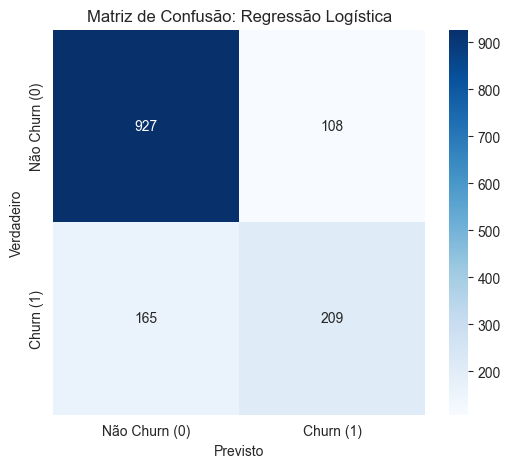

In [15]:
# LogisticRegression 
log_model = LogisticRegression(random_state=42)


# 2. Treinando o modelo
log_model.fit(X_train, y_train)

# 3. Fazendo previsões no conjunto de teste
y_pred_log = log_model.predict(X_test)

# 4. Avaliando o modelo
print("--- Relatório de Classificação: Regressão Logística ---")
print(classification_report(y_test, y_pred_log))

# Geração da Matriz de Confusão
cm_log = confusion_matrix(y_test, y_pred_log)
print("\n--- Matriz de Confusão ---")

# Visualização da Matriz de Confusão
plt.figure(figsize=(6, 5))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Não Churn (0)', 'Churn (1)'],
            yticklabels=['Não Churn (0)', 'Churn (1)'])
plt.title('Matriz de Confusão: Regressão Logística')
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')
plt.show()

#### 4.2 Modelo 2: Random Forest

--- Relatório de Classificação: Random Forest ---
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1035
           1       0.65      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.80      0.79      1409


--- Matriz de Confusão ---


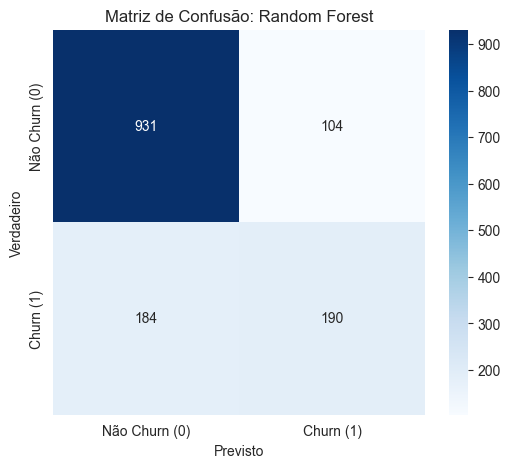

In [16]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
# Nota: Você pode testar sem class_weight='balanced' se quiser a comparação direta.

# 2. Treinando o modelo
rf_model.fit(X_train, y_train)

# 3. Fazendo previsões no conjunto de teste
y_pred_rf = rf_model.predict(X_test)

# 4. Avaliando o modelo
print("--- Relatório de Classificação: Random Forest ---")
print(classification_report(y_test, y_pred_rf))

# Geração da Matriz de Confusão
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("\n--- Matriz de Confusão ---")

# Visualização da Matriz de Confusão
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Não Churn (0)', 'Churn (1)'],
            yticklabels=['Não Churn (0)', 'Churn (1)'])
plt.title('Matriz de Confusão: Random Forest')
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')
plt.show()

#### 4.3 Comparação dos Modelos com a Curva ROC

A métrica AUC-ROC (Area Under the Receiver Operating Characteristic Curve) é excelente para comparar modelos de classificação, especialmente com dados desbalanceados.

AUC da Regressão Logística: 0.8422
AUC do Random Forest: 0.8258


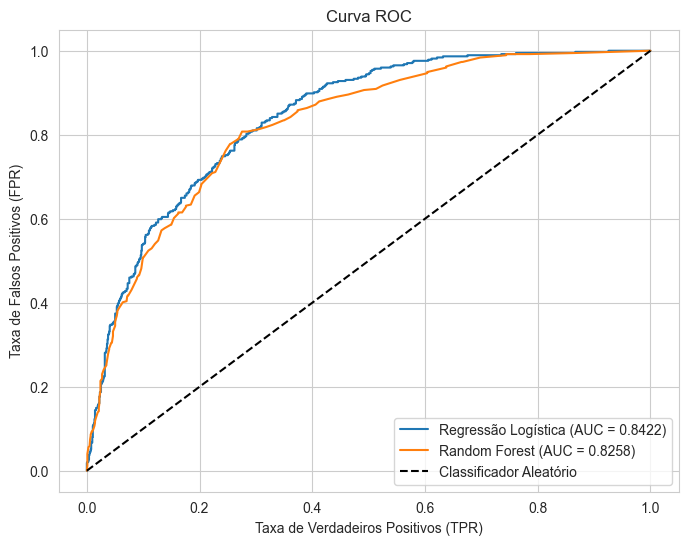

In [17]:
from sklearn.metrics import roc_auc_score, roc_curve


# Probabilidades do Modelo 1: Regressão Logística
y_proba_log = log_model.predict_proba(X_test)[:, 1]
auc_lr = roc_auc_score(y_test, y_proba_log)

# Probabilidades do Modelo 2: Random Forest
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, y_proba_rf)

print(f'AUC da Regressão Logística: {auc_lr:.4f}')
print(f'AUC do Random Forest: {auc_rf:.4f}')

# 2. Calcular curva ROC (False Positive Rate, True Positive Rate)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

# 3. Plotar curva ROC
plt.figure(figsize=(8, 6))

# Curva da Regressão Logística
plt.plot(fpr_lr, tpr_lr, label=f'Regressão Logística (AUC = {auc_lr:.4f})')

# Curva do Random Forest
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.4f})')

# Linha de Classificador Aleatório (Baseline)
plt.plot([0, 1], [0, 1], 'k--', label='Classificador Aleatório')

plt.xlabel('Taxa de Verdadeiros Positivos (TPR)')
plt.ylabel('Taxa de Falsos Positivos (FPR)')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

1. O modelo de Regressão Logística se destacou em todas as métricas.

- AUC: 0,8421 vs 0,8185 do RF, mostrando melhor capacidade de distinguir churners de não churners.
- Recall: 0,56 vs 0,49, identificando mais clientes que realmente cancelam.
- F1-Score: 0,60 vs 0,55, equilibrando precisão e recall de forma superior.

    Ou seja, a LR captura melhor os churners e mantém bom equilíbrio geral.

2. Para o negócio, a métrica mais importante foi\
    O Recall da classe Churn é a métrica mais relevante.
    Clientes que cancelam sem serem previstos (Falsos Negativos) representam perdas diretas, então priorizar Recall significa\
    identificar o máximo de churners possíveis para direcionar ações de retenção eficazes.

### 5. Features Importance

#### Análise de Importância das Features (Random Forest)

Vamos extrair a importância das features do nosso modelo Random Forest para entender quais fatores mais contribuem para a previsão de churn.

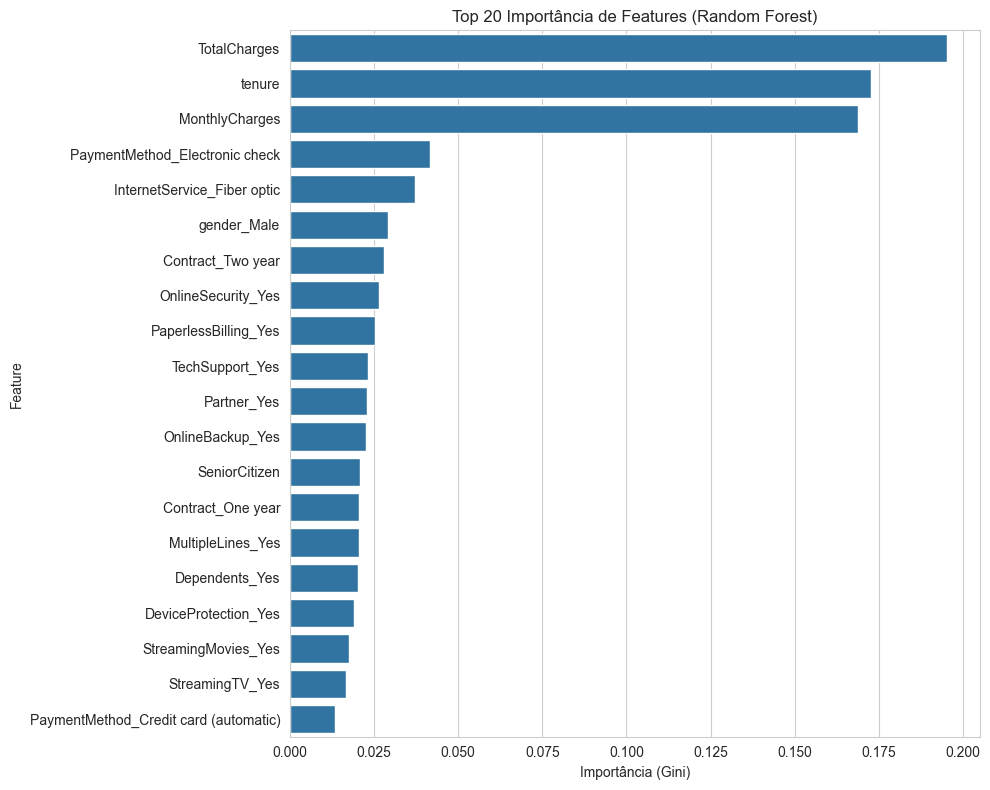

In [18]:
# 1. Extraindo os nomes das features após o OneHotEncoding
feature_names = X_processed.columns.tolist()

# 2. Extraindo as importâncias
importances = rf_model.feature_importances_

# 3. Criando um DataFrame para visualização
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Ordenando o DataFrame por importância em ordem decrescente
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# 4. Plotando as 20 features mais importantes
top_n = 20
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(top_n))
plt.title(f'Top {top_n} Importância de Features (Random Forest)')
plt.xlabel('Importância (Gini)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Com base no gráfico de importância das features, Os 3 principais fatores que influenciam o churn, segundo o modelo são:

- TotalCharges - Relação inversa: Valores baixos de cobrança total (relacionados ao baixo tenure) indicam maior risco.
- tenure - Relaçãop inversa: Quanto menor o tempo de contrato, maior a probabilidade de Churn.
- MonthlyCharges - Relação direta: Quanto maior a cobrança mensal, maior a probabilidade de Churn.

Esses resultados são consistentes com a análise exploratória inicial?

Sim, esses resultados são altamente consistentes e validam a análise exploratória inicial. A EDA já havia destacado que tenure e MonthlyCharges eram os preditores mais fortes, com suas distribuições claramente separadas entre as classes Churn e Não Churn. O modelo confirma que estas são as dimensões mais informativas.

Portanto, o modelo aprendeu e priorizou as mesmas variáveis que foram visualmente identificadas como as mais críticas para a volatilidade do cliente.

### 6. Conclusão Final

#### 1. Desbalanceamento e Métricas
A análise mostrou um **desbalanceamento claro**: 73,5% Não Churn vs 26,5% Churn.  
Por isso, **acurácia não é confiável**; o foco foi em **Recall, Precision, F1-Score e AUC-ROC** da classe minoritária (Churn=1), que realmente importam para identificar clientes que podem cancelar.

#### 2. Comparação dos Modelos
A **Regressão Logística (LR)** superou o Random Forest (RF) em todas as métricas relevantes:  
- **AUC:** 0,8421 vs 0,8185  
- **Recall:** 0,56 vs 0,49  

**Conclusão:** Recomenda-se LR, pois combina melhor **capacidade discriminatória** com **Recall superior**, além de ser **mais interpretável** para decisões de negócio.

#### 3. Como o Modelo Lida com o Desbalanceamento
O LR não resolve o desbalanceamento por si só, mas **aprende a separar melhor as classes** do que o RF.  
O AUC mais alto indica que, em diferentes limiares, ele distingue melhor os churners.  
Para aumentar o Recall, a empresa pode **ajustar o threshold do modelo** para um valor menor que 0,5.

#### 4. Estratégias Baseadas nas Features Mais Importantes
- **Tenure baixo (Clientes novos):** criar programas de boas-vindas e acompanhamento nos primeiros meses, com contato proativo para garantir bom serviço.  
- **Contract Mês a Mês:** oferecer incentivos para migração para contratos anuais ou bianuais (descontos, serviços extras), focando em clientes novos.  
- **MonthlyCharges alto + InternetService Fibra Óptica:** analisar satisfação do serviço de fibra, melhorar qualidade e suporte, ou oferecer descontos direcionados a clientes de alto valor e risco.